# Pit Stop Submission Blender

*Link to original notebook:* https://www.kaggle.com/code/flexonafft/f1-best-catboost-solution-0-95259

This notebook creates additional submission files from already trained seed submissions. It does not train models. It compares probability distributions, rank agreement, and pairwise correlations so blend variants can be inspected before submission.

In [1]:
"""Import libraries, set display style, and define shared formatting helpers."""

from pathlib import Path
from html import escape

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

TARGET_COL = "PitNextLap"
ID_COL = "id"
CLIP_LOW = 1e-7
CLIP_HIGH = 1 - 1e-7

INPUT_FILES = {
    "seed_42": "submission_seed_42.csv",
    "seed_777": "submission_seed_777.csv",
    "seed_2024": "submission_seed_2024.csv",
    "prob_mean": "submission_prob_mean.csv",
}


def fmt_value(value):
    if pd.isna(value):
        return "-"
    if isinstance(value, (np.integer, int)):
        return f"{int(value):,}"
    if isinstance(value, (np.floating, float)):
        if abs(value) >= 1000:
            return f"{value:,.0f}"
        return f"{value:.6f}".rstrip("0").rstrip(".")
    return str(value)


def show_title(title, subtitle=None):
    subtitle_html = f'<div style="color:#6b7280;font-size:13px;margin-top:3px;">{escape(str(subtitle))}</div>' if subtitle else ""
    display(HTML(
        f"""
        <div style="margin:18px 0 10px 0;padding-bottom:8px;border-bottom:1px solid #e5e7eb;">
          <div style="font-size:18px;font-weight:700;color:#111827;">{escape(str(title))}</div>
          {subtitle_html}
        </div>
        """
    ))


def show_metric_cards(title, data, columns=4):
    if isinstance(data, pd.DataFrame):
        data = data.iloc[0].to_dict() if len(data) else {}
    cards = []
    for key, value in data.items():
        cards.append(
            f"""
            <div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 12px;background:#ffffff;">
              <div style="font-size:11px;text-transform:uppercase;letter-spacing:.04em;color:#6b7280;">{escape(str(key).replace('_', ' '))}</div>
              <div style="font-size:18px;font-weight:700;color:#111827;margin-top:4px;">{escape(fmt_value(value))}</div>
            </div>
            """
        )
    display(HTML(
        f"""
        <div style="margin:12px 0;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          <div style="display:grid;grid-template-columns:repeat({columns},minmax(0,1fr));gap:8px;">
            {''.join(cards)}
          </div>
        </div>
        """
    ))


def show_records(title, df, max_rows=12, columns=2):
    view = df.head(max_rows).copy()
    records = []
    for _, row in view.iterrows():
        fields = []
        for key, value in row.items():
            fields.append(
                f"<div><span style='color:#6b7280'>{escape(str(key).replace('_', ' '))}</span>: "
                f"<strong style='color:#111827'>{escape(fmt_value(value))}</strong></div>"
            )
        records.append(
            f"""
            <div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 12px;background:#ffffff;">
              <div style="font-size:13px;line-height:1.65;">{''.join(fields)}</div>
            </div>
            """
        )
    more = "" if len(df) <= max_rows else f"<div style='color:#6b7280;font-size:12px;margin-top:6px;'>Showing {max_rows} of {len(df)} records</div>"
    display(HTML(
        f"""
        <div style="margin:12px 0;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          <div style="display:grid;grid-template-columns:repeat({columns},minmax(0,1fr));gap:8px;">
            {''.join(records)}
          </div>
          {more}
        </div>
        """
    ))


## Load Submissions

In [2]:
"""Load seed submission files, validate row alignment, and collect predictions."""

def find_input_file(filename):
    direct_path = Path(filename)
    if direct_path.exists():
        return direct_path

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        matches = sorted(kaggle_input.rglob(filename))
        if matches:
            return matches[0]

    return None


resolved_files = {name: find_input_file(filename) for name, filename in INPUT_FILES.items()}
missing_files = [INPUT_FILES[name] for name, path in resolved_files.items() if path is None]
if missing_files:
    raise FileNotFoundError(
        "Missing input submission files: "
        + ", ".join(missing_files)
        + ". Add the output notebook as Kaggle input, or place these CSV files in the working directory."
    )

submissions = {}
base_ids = None
for name, path in resolved_files.items():
    df = pd.read_csv(path)
    filename = str(path)
    if ID_COL not in df.columns:
        raise ValueError(f"{filename} does not contain {ID_COL} column.")
    target_candidates = [col for col in df.columns if col != ID_COL]
    if TARGET_COL in df.columns:
        target_col = TARGET_COL
    elif len(target_candidates) == 1:
        target_col = target_candidates[0]
    else:
        raise ValueError(f"Cannot detect target column in {filename}.")

    if base_ids is None:
        base_ids = df[ID_COL].copy()
    elif not base_ids.equals(df[ID_COL]):
        raise ValueError(f"ID order mismatch in {filename}.")

    submissions[name] = np.clip(df[target_col].to_numpy(dtype=float), CLIP_LOW, CLIP_HIGH)

prediction_df = pd.DataFrame(submissions)
prediction_df.insert(0, ID_COL, base_ids.values)

load_report = pd.DataFrame(
    [
        {"name": name, "file": str(resolved_files[name]), "rows": len(prediction_df), "mean": values.mean(), "std": values.std()}
        for name, values in submissions.items()
    ]
)

show_title("Loaded submissions", "Seed predictions and the probability mean baseline")
show_records("Input files", load_report.round(6), max_rows=len(load_report), columns=2)
show_metric_cards("Prediction matrix", {"rows": len(prediction_df), "prediction_columns": len(submissions)}, columns=2)


## Compare Predictions

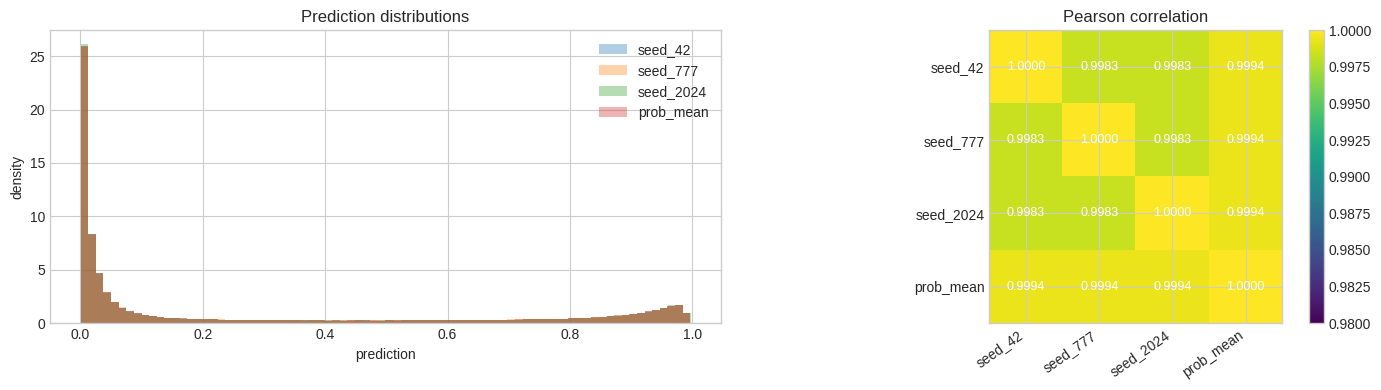

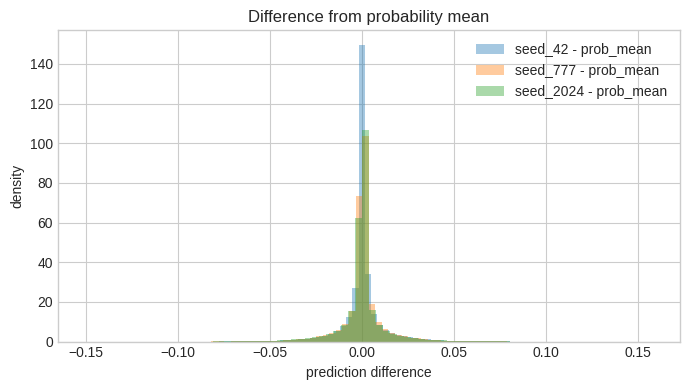

In [3]:
"""Compare loaded submissions with summary statistics, correlations, and distribution plots."""

summary_rows = []
for name, values in submissions.items():
    summary_rows.append(
        {
            "variant": name,
            "mean": values.mean(),
            "std": values.std(),
            "min": values.min(),
            "p01": np.percentile(values, 1),
            "p50": np.percentile(values, 50),
            "p99": np.percentile(values, 99),
            "max": values.max(),
        }
    )
summary_df = pd.DataFrame(summary_rows)

corr_df = pd.DataFrame(submissions).corr(method="pearson")
rank_corr_df = pd.DataFrame(submissions).corr(method="spearman")

show_title("Prediction comparison", "Distribution and agreement between seed submissions")
show_records("Summary statistics", summary_df.round(6), max_rows=len(summary_df), columns=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, values in submissions.items():
    axes[0].hist(values, bins=80, alpha=0.35, density=True, label=name)
axes[0].set_title("Prediction distributions")
axes[0].set_xlabel("prediction")
axes[0].set_ylabel("density")
axes[0].legend()

im = axes[1].imshow(corr_df.values, vmin=0.98, vmax=1.0, cmap="viridis")
axes[1].set_title("Pearson correlation")
axes[1].set_xticks(range(len(corr_df.columns)))
axes[1].set_xticklabels(corr_df.columns, rotation=35, ha="right")
axes[1].set_yticks(range(len(corr_df.index)))
axes[1].set_yticklabels(corr_df.index)
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        axes[1].text(j, i, f"{corr_df.iloc[i, j]:.4f}", ha="center", va="center", color="white", fontsize=9)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for name in [col for col in prediction_df.columns if col != ID_COL and col != "prob_mean"]:
    diff = prediction_df[name] - prediction_df["prob_mean"]
    ax.hist(diff, bins=80, alpha=0.4, density=True, label=f"{name} - prob_mean")
ax.set_title("Difference from probability mean")
ax.set_xlabel("prediction difference")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()


## Create Blends

In [4]:
"""Create pair, weighted, and rank-based blends from loaded submission predictions."""

seed_names = [name for name in ["seed_42", "seed_777", "seed_2024"] if name in submissions]
seed_matrix = np.vstack([submissions[name] for name in seed_names])


def normalize_0_1(values):
    values = np.asarray(values, dtype=float)
    return (values - values.min()) / (values.max() - values.min() + 1e-12)


def rank_average(pred_matrix):
    ranks = np.vstack(
        [normalize_0_1(pd.Series(pred).rank(method="average").to_numpy()) for pred in pred_matrix]
    )
    return np.clip(ranks.mean(axis=0), CLIP_LOW, CLIP_HIGH)

blend_predictions = {}
blend_predictions["prob_mean"] = np.clip(seed_matrix.mean(axis=0), CLIP_LOW, CLIP_HIGH)
blend_predictions["rank_mean"] = rank_average(seed_matrix)

pair_specs = {
    "pair_42_777": ["seed_42", "seed_777"],
    "pair_42_2024": ["seed_42", "seed_2024"],
    "pair_777_2024": ["seed_777", "seed_2024"],
}
for name, parts in pair_specs.items():
    if all(part in submissions for part in parts):
        blend_predictions[name] = np.clip(np.vstack([submissions[part] for part in parts]).mean(axis=0), CLIP_LOW, CLIP_HIGH)

weight_specs = {
    "weight_40_40_20": {"seed_42": 0.40, "seed_777": 0.40, "seed_2024": 0.20},
    "weight_45_45_10": {"seed_42": 0.45, "seed_777": 0.45, "seed_2024": 0.10},
    "weight_50_25_25": {"seed_42": 0.50, "seed_777": 0.25, "seed_2024": 0.25},
    "weight_25_50_25": {"seed_42": 0.25, "seed_777": 0.50, "seed_2024": 0.25},
    "weight_25_25_50": {"seed_42": 0.25, "seed_777": 0.25, "seed_2024": 0.50},
}
for name, weights in weight_specs.items():
    if all(part in submissions for part in weights):
        pred = np.zeros(len(base_ids), dtype=float)
        for part, weight in weights.items():
            pred += weight * submissions[part]
        blend_predictions[name] = np.clip(pred, CLIP_LOW, CLIP_HIGH)

blend_predictions["prob_rank_70_30"] = np.clip(0.70 * blend_predictions["prob_mean"] + 0.30 * blend_predictions["rank_mean"], CLIP_LOW, CLIP_HIGH)
blend_predictions["prob_rank_50_50"] = np.clip(0.50 * blend_predictions["prob_mean"] + 0.50 * blend_predictions["rank_mean"], CLIP_LOW, CLIP_HIGH)

show_title("Blend variants", "Generated without retraining any model")
show_metric_cards("Blend count", {"variants": len(blend_predictions), "rows": len(base_ids)}, columns=2)


## Save and Inspect Blend Files

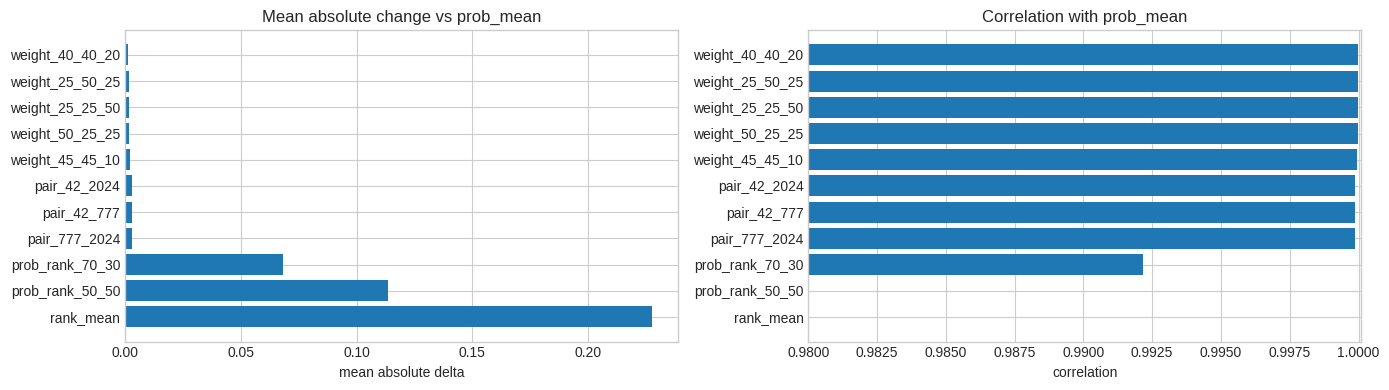

In [5]:
"""Save blend submission files and show comparison charts against the probability mean."""


def save_submission(filename, pred):
    sub = pd.DataFrame({ID_COL: base_ids.values, TARGET_COL: np.clip(pred, CLIP_LOW, CLIP_HIGH)})
    sub.to_csv(filename, index=False)

blend_rows = []
for name, pred in blend_predictions.items():
    filename = f"submission_{name}.csv"
    save_submission(filename, pred)
    delta = pred - blend_predictions["prob_mean"]
    blend_rows.append(
        {
            "variant": name,
            "file": filename,
            "mean": pred.mean(),
            "std": pred.std(),
            "min": pred.min(),
            "max": pred.max(),
            "corr_prob_mean": np.corrcoef(pred, blend_predictions["prob_mean"])[0, 1],
            "mean_abs_delta": np.abs(delta).mean(),
            "p95_abs_delta": np.percentile(np.abs(delta), 95),
        }
    )

blend_summary = pd.DataFrame(blend_rows).sort_values(["mean_abs_delta", "variant"]).reset_index(drop=True)
blend_summary.to_csv("blend_summary.csv", index=False)

# Keep baseline probability mean as the default safe submission.
save_submission("submission.csv", blend_predictions["prob_mean"])

show_title("Saved blend files", "Default submission.csv is the probability mean baseline")
show_records("Blend summary", blend_summary.round(6), max_rows=len(blend_summary), columns=2)
show_metric_cards(
    "Default submission",
    {
        "source_variant": "prob_mean",
        "file": "submission.csv",
        "mean": blend_predictions["prob_mean"].mean(),
        "std": blend_predictions["prob_mean"].std(),
    },
    columns=4,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_df = blend_summary[blend_summary["variant"] != "prob_mean"].copy()
axes[0].barh(plot_df["variant"], plot_df["mean_abs_delta"])
axes[0].set_title("Mean absolute change vs prob_mean")
axes[0].set_xlabel("mean absolute delta")
axes[0].invert_yaxis()

axes[1].barh(plot_df["variant"], plot_df["corr_prob_mean"])
axes[1].set_title("Correlation with prob_mean")
axes[1].set_xlabel("correlation")
axes[1].set_xlim(max(0.98, plot_df["corr_prob_mean"].min() - 0.001), 1.0001)
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()
